In [41]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Processed Dataset(from Q1)

In [42]:
# Load the dataset
df = pd.read_csv('TaxiData.csv')

# Convert trip_start_timestamp to datetime
df['trip_start_timestamp'] = pd.to_datetime(df['trip_start_timestamp'], unit='s')

# Ensure community areas are categorical
df['pickup_community_area'] = df['pickup_community_area'].astype('category')
df['dropoff_community_area'] = df['dropoff_community_area'].astype('category')

import warnings
warnings.filterwarnings("ignore")
# Impute numerical columns with mean
numerical_cols = ['fare', 'trip_miles', 'trip_seconds', 'tips']
for col in numerical_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Impute categorical columns with mode or label as 'Unknown'
categorical_cols = ['payment_type', 'company','pickup_census_tract','dropoff_census_tract']
for col in categorical_cols:
    df[col].fillna('Unknown', inplace=True)

# Drop rows with missing latitude/longitude data if they are critical
df.dropna(subset=['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude'], inplace=True)

## 3.a Fare and Tip Distribution

(a)  Histograms and Box plots

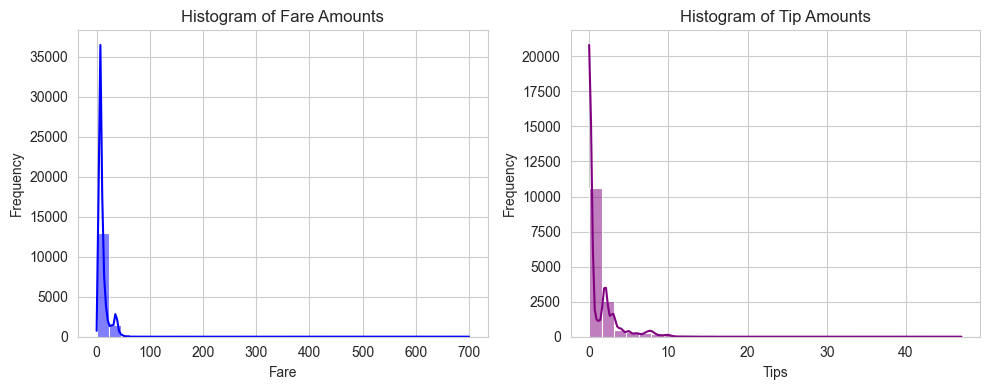

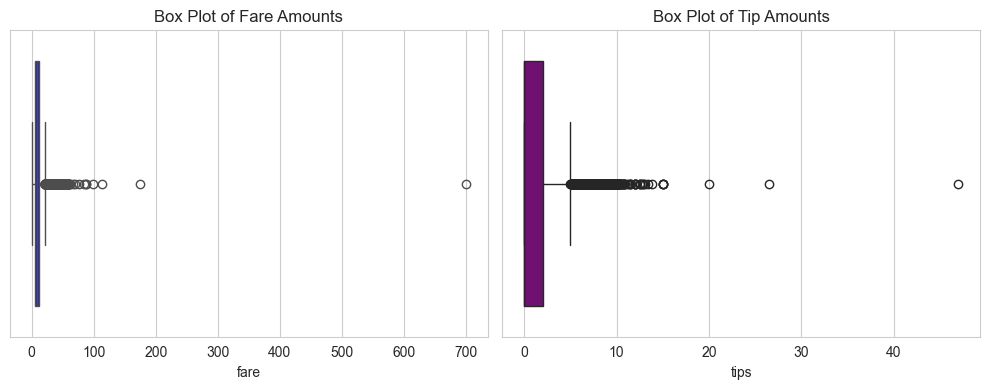

In [43]:
df['trip_start_hour'] = df['trip_start_timestamp'].dt.hour
df['trip_start_day'] = df['trip_start_timestamp'].dt.day_name()
df['trip_start_month'] = df['trip_start_timestamp'].dt.month_name()

sns.set_style("whitegrid")

plt.figure(figsize=(10, 4))

# Fare Histogram
plt.subplot(1, 2, 1)
sns.histplot(df['fare'], bins=30, kde=True, color='blue')
plt.title('Histogram of Fare Amounts')
plt.xlabel('Fare')
plt.ylabel('Frequency')

# Tip Histogram
plt.subplot(1, 2, 2)
sns.histplot(df['tips'], bins=30, kde=True, color='purple')
plt.title('Histogram of Tip Amounts')
plt.xlabel('Tips')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Box Plots for Fare and Tip Amounts
plt.figure(figsize=(10, 4))

# Fare Box Plot
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='fare', color='blue')
plt.title('Box Plot of Fare Amounts')

# Tip Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='tips', color='purple')
plt.title('Box Plot of Tip Amounts')

plt.tight_layout()
plt.show()

(b) Range, outlier and cluster

In [44]:
fare_summary = df['fare'].describe()
tip_summary = df['tips'].describe()

fare_iqr = fare_summary['75%'] - fare_summary['25%']
fare_upper_bound = fare_summary['75%'] + 1.5 * fare_iqr
fare_outliers = df[df['fare'] > fare_upper_bound]

tip_iqr = tip_summary['75%'] - tip_summary['25%']
tip_upper_bound = tip_summary['75%'] + 1.5 * tip_iqr
tip_outliers = df[df['tips'] > tip_upper_bound]

print("\nFare Outliers Above Upper Bound:")
print(fare_outliers[['fare']])

print("\nTip Outliers Above Upper Bound:")
print(tip_outliers[['tips']])


Fare Outliers Above Upper Bound:
        fare
72     26.05
95     25.45
101    23.85
106    38.45
107    35.85
...      ...
14761  38.85
14782  35.25
14926  26.25
14931  23.05
14948  35.65

[1678 rows x 1 columns]

Tip Outliers Above Upper Bound:
        tips
108     7.45
110     8.85
111     7.00
113     7.00
114     7.33
...      ...
14609   7.85
14736   6.00
14737   6.00
14761  10.20
14948   5.65

[752 rows x 1 columns]


(c) Statistical Summary

In [45]:
print("Fare Summary Statistics:")
print(fare_summary)
print("\nTip Summary Statistics:")
print(tip_summary)

Fare Summary Statistics:
count    14520.000000
mean        11.321727
std         11.006953
min          0.000000
25%          5.850000
50%          7.850000
75%         12.050000
max        700.070000
Name: fare, dtype: float64

Tip Summary Statistics:
count    14520.000000
mean         1.035544
std          2.031519
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max         47.000000
Name: tips, dtype: float64


```
Analysis:
1. Fare 

Outliers: The high fare outliers may correspond to long-distance or special trips (e.g., airport transfers).
Clusters: The majority of trips fall in the lower fare range, which suggests that most trips are short or average in distance.

2. Tip

Outliers: High tip outliers may represent cases where passengers are especially generous or perhaps cases of long or high-fare trips.
Clusters: The presence of clusters around zero or low values suggests that low or no tipping is common, which could be due to the nature of the service, payment method, or customer preference.
```

## 3.b Payment method insights

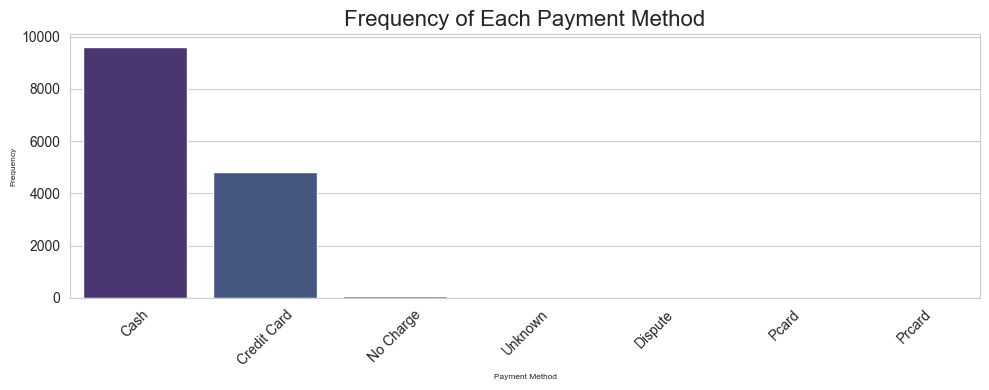

In [46]:
payment_counts = df['payment_type'].value_counts()

# Bar chart
plt.figure(figsize=(10,4))
sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='viridis')
plt.title('Frequency of Each Payment Method', fontsize=16)
plt.xlabel('Payment Method', fontsize=6)
plt.ylabel('Frequency', fontsize=6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


```
Implications:
```

## 3.c Tips by Payment Method

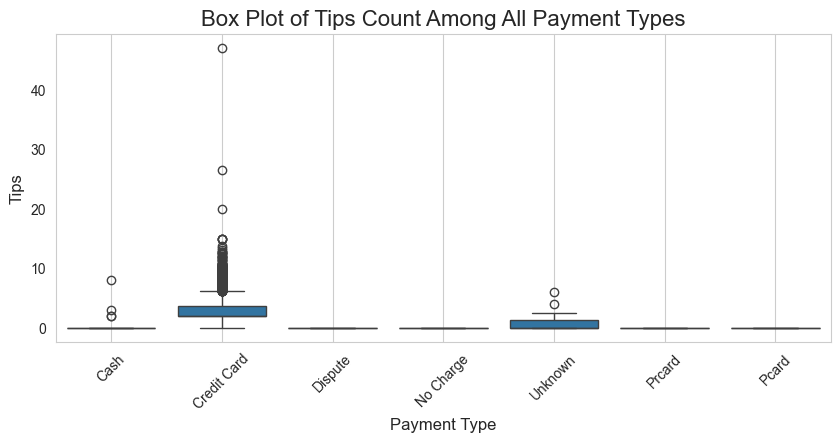

  payment_type      tips
0         Cash  0.001568
1  Credit Card  3.116804
2      Dispute  0.000000
3    No Charge  0.000000
4        Pcard  0.000000
5       Prcard  0.000000
6      Unknown  0.903182


In [47]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='payment_type', y='tips')
plt.title('Box Plot of Tips Count Among All Payment Types', fontsize=16)
plt.xlabel('Payment Type', fontsize=12)
plt.ylabel('Tips', fontsize=12)
plt.xticks(rotation=45)
plt.grid()
plt.show()

avg_tips_per_payment = df.groupby('payment_type')['tips'].mean().reset_index()
print(avg_tips_per_payment)


```
Interpretation:
Credit card payments tend to yield the highest average tipping amounts, with significant variability and outliers. Cash and unknown methods also have low tips but show less variability. Other payment types have negligible tipping amounts.
```

##  3.d Fare vs. Distance

(a) Scatterplot between trip distance and fare

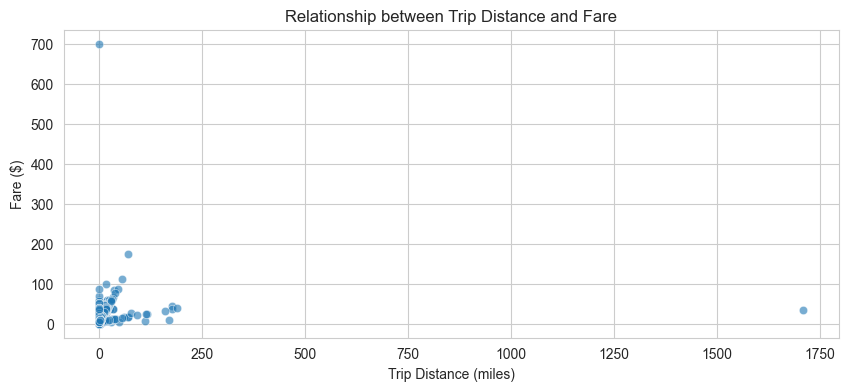

In [48]:
plt.figure(figsize=(10, 4))
sns.scatterplot(data=df, x='trip_miles', y='fare', alpha=0.6)
plt.title('Relationship between Trip Distance and Fare')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare ($)')
plt.show()


(b) Correlation Coefficient

In [49]:
correlation_coefficient = df['trip_miles'].corr(df['fare'])
print(f"Correlation Coefficient between Trip Distance and Fare: {correlation_coefficient:.2f}")


Correlation Coefficient between Trip Distance and Fare: 0.21


```
Interpretation:
The correlation is positive, suggesting that as trip distance increases, fare also tends to increase. The low correlation implies that distance alone does not strongly determine the fare. Other factors, such as time spent on the trip, traffic conditions, or additional fees, may play a larger role in fare calculations.
```